In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

In [ ]:
dataset_path = "/content/drive/MyDrive/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

In [ ]:
!pip install git+https://github.com/openai/CLIP.git

import torch
import clip
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-ibyjpa8x
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-ibyjpa8x
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=c790514f6d5ce5781c5f8c17e7c8fb6c724efcbb8a731a5c1bd621eaf18b97b8
  Stored in directory: /tmp/pip-ephem-wheel-cache-raccihj1/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 112MiB/s]


In [ ]:
from tqdm.auto import tqdm

In [ ]:
class CTDataset(Dataset):
    def __init__(self, root_dir, transform):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        self.samples = []

        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for img in os.listdir(cls_path):
                self.samples.append((os.path.join(cls_path, img), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        return image, label

In [ ]:
dataset_path = "/content/drive/MyDrive/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"

dataset = CTDataset(dataset_path, preprocess)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

import torch.nn as nn

class ImprovedCLIPClassifier(nn.Module):
    def __init__(self, clip_model, num_classes):
        super().__init__()
        self.clip = clip_model

        self.classifier = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.clip.encode_image(x)

        return self.classifier(features.float())

In [ ]:
num_classes = len(dataset.classes)

model_improved = ImprovedCLIPClassifier(model, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_improved.classifier.parameters(), lr=5e-4)

In [ ]:
def train(model, loader):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{100*correct/total:.2f}%"
        )

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [ ]:
patience = 3
best_val = 0
counter = 0

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


In [ ]:
print(torch.cuda.is_available())
print(device)
print(next(model_improved.parameters()).device)

True
cuda
cuda:0


In [ ]:
epochs = 20

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    train_loss, train_acc = train(model_improved, train_loader)
    val_loss, val_acc = evaluate(model_improved, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")
    print("-"*40)

    # ✅ Save best model
    if val_acc > best_val:
        best_val = val_acc
        counter = 0
        torch.save(model_improved.state_dict(), "/content/drive/MyDrive/best_improved_model.pth")
        print("✅ Best model saved!")
    else:
        counter += 1

    # 🛑 Early stopping
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break


Epoch 1/20


Training:   0%|          | 0/312 [00:00<?, ?it/s]

In [ ]:
import numpy as np

np.save("/content/drive/MyDrive/train_losses.npy", train_losses)
np.save("/content/drive/MyDrive/val_losses.npy", val_losses)
np.save("/content/drive/MyDrive/train_acc.npy", train_accuracies)
np.save("/content/drive/MyDrive/val_acc.npy", val_accuracies)

print("✅ Curves saved")

✅ Curves saved


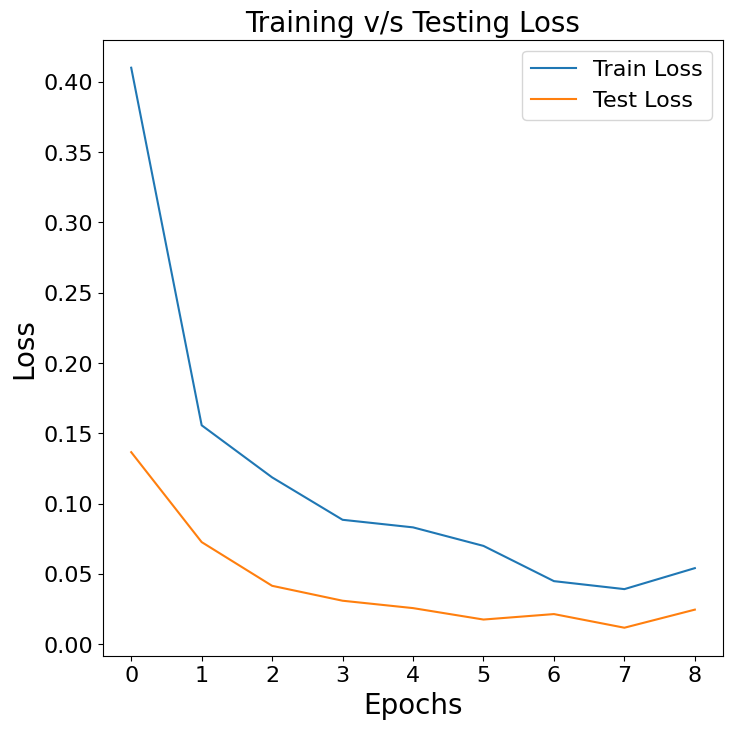

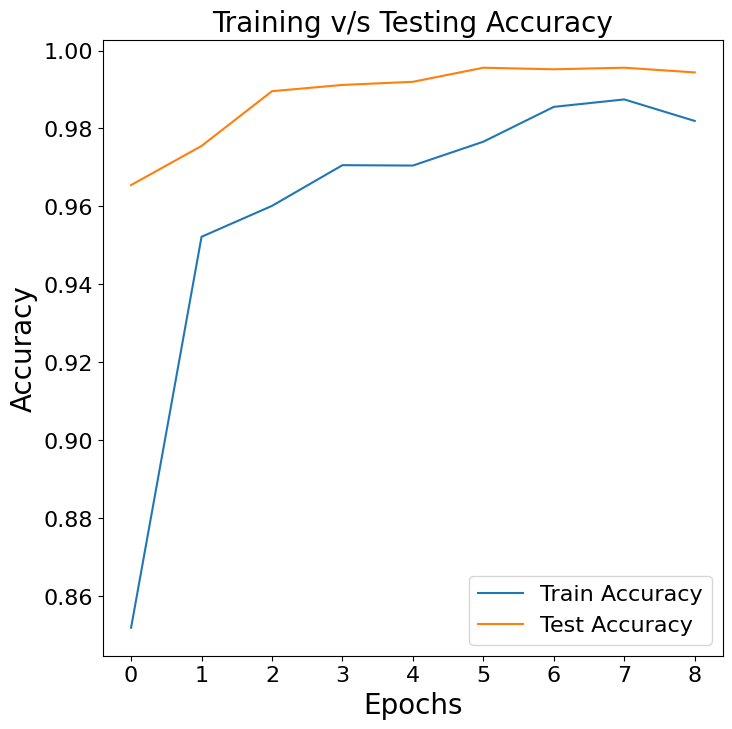

In [ ]:
import matplotlib.pyplot as plt

# Loss Plot
plt.figure(figsize=(8,8))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Test Loss")
plt.legend(fontsize=16)
plt.title("Training v/s Testing Loss", fontsize=20)
plt.xlabel("Epochs", fontsize=20)
plt.ylabel("Loss", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()


# Accuracy Plot
plt.figure(figsize=(8,8))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Test Accuracy")
plt.legend(fontsize=16)
plt.title("Training v/s Testing Accuracy", fontsize=20)
plt.xlabel("Epochs", fontsize=20)
plt.ylabel("Accuracy", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

model_improved.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_improved(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[755   0   0   0]
 [  2 986   1   6]
 [  5   0 286   0]
 [  0   0   0 449]]


In [ ]:
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

              precision    recall  f1-score   support

        Cyst       0.99      1.00      1.00       755
      Normal       1.00      0.99      1.00       995
       Stone       1.00      0.98      0.99       291
       Tumor       0.99      1.00      0.99       449

    accuracy                           0.99      2490
   macro avg       0.99      0.99      0.99      2490
weighted avg       0.99      0.99      0.99      2490



In [ ]:
accuracy = np.trace(cm) / np.sum(cm)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9944


In [ ]:
TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (TP + FP + FN)

# Micro-averaged (global)
precision = np.sum(TP) / (np.sum(TP) + np.sum(FP) + 1e-8)
recall = np.sum(TP) / (np.sum(TP) + np.sum(FN) + 1e-8)
specificity = np.sum(TN) / (np.sum(TN) + np.sum(FP) + 1e-8)

print(f"Precision: {precision:.4f}")
print(f"Sensitivity (Recall): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")

Precision: 0.9944
Sensitivity (Recall): 0.9944
Specificity: 0.9981


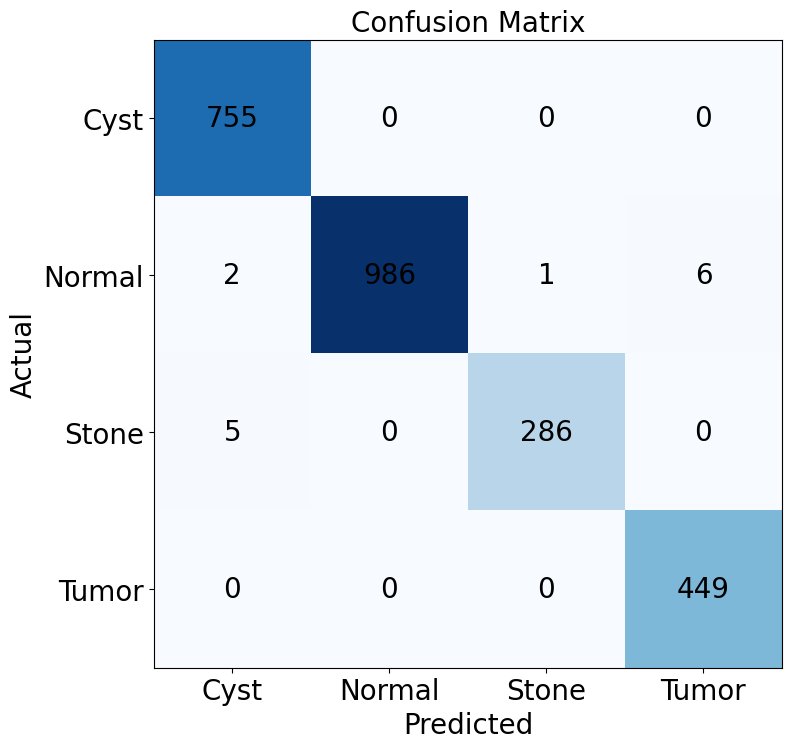

In [ ]:
class_names = dataset.classes   # e.g. ['Normal', 'Cyst', 'Tumor', 'Stone']

plt.figure(figsize=(8,8))
plt.imshow(cm, cmap='Blues')

plt.title("Confusion Matrix", fontsize=20)
plt.xlabel("Predicted", fontsize=20)
plt.ylabel("Actual", fontsize=20)

plt.xticks(ticks=range(len(class_names)), labels=class_names, fontsize=20)
plt.yticks(ticks=range(len(class_names)), labels=class_names, fontsize=20)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black", fontsize=20)

plt.tight_layout()
plt.show()

Feature Shape: (2490, 512)


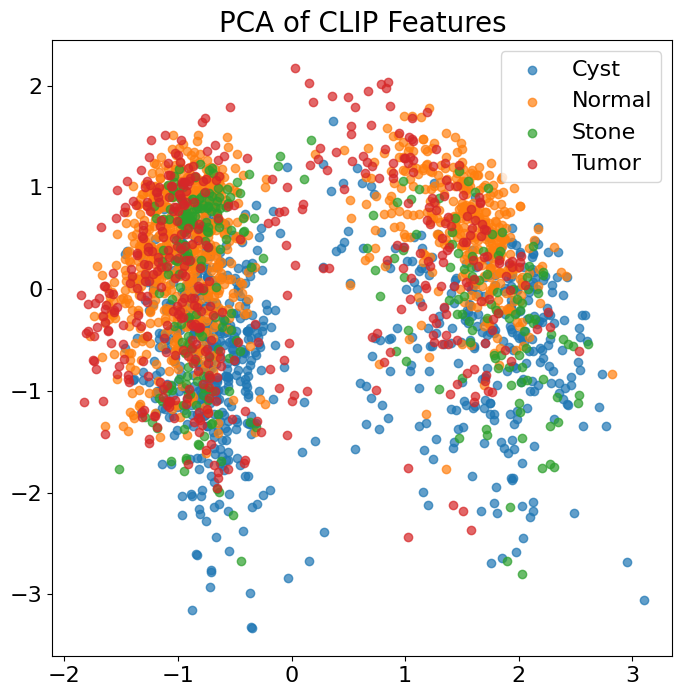

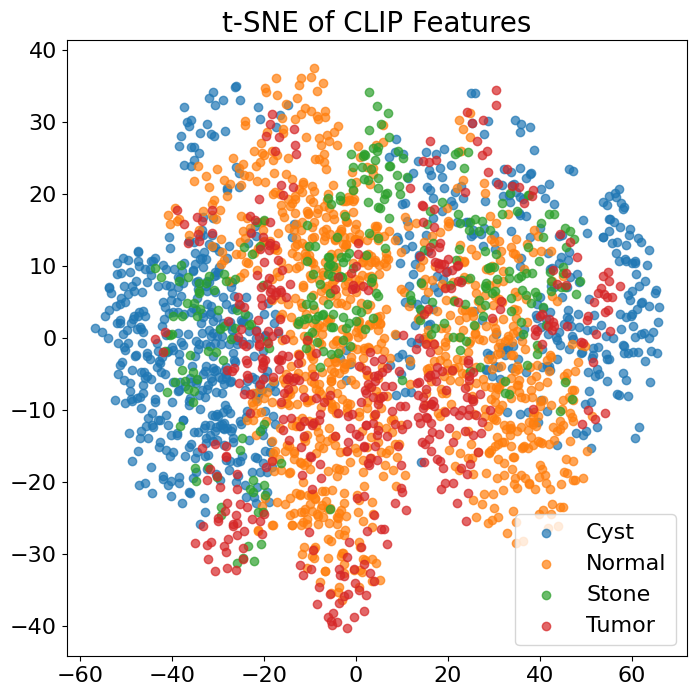

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load best model
model_improved.load_state_dict(
    torch.load("/content/drive/MyDrive/best_improved_model.pth")
)
model_improved.eval()

features = []
labels_all = []

with torch.no_grad():
    for images, labels in val_loader:   # or test_loader if you have one
        images = images.to(device)

        feat = model_improved.clip.encode_image(images)
        feat = feat.float()

        features.append(feat.cpu().numpy())
        labels_all.append(labels.numpy())

X = np.vstack(features)
y = np.hstack(labels_all)

# Save raw features too
np.save("/content/drive/MyDrive/features.npy", X)
np.save("/content/drive/MyDrive/labels.npy", y)

print("Feature Shape:", X.shape)

# PCA
pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,8))
for i, cls in enumerate(dataset.classes):
    idx = y == i
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=cls, alpha=0.7)

plt.title("PCA of CLIP Features", fontsize=20)
plt.legend(fontsize=16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()

# t-SNE
tsne = TSNE(
    n_components=3,
    perplexity=80,
    learning_rate=200,
    random_state=42
)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,8))
for i, cls in enumerate(dataset.classes):
    idx = y == i
    plt.scatter(X_tsne[idx,0], X_tsne[idx,1], label=cls, alpha=0.7)

plt.title("t-SNE of CLIP Features", fontsize=20)
plt.legend(fontsize=16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.show()